In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [4]:
tips = sns.load_dataset("tips")

In [5]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
tips['total_bill'].mean()

np.float64(19.78594262295082)

In [8]:
bill = tips['total_bill']

In [9]:
bill.describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

In [11]:
bill.mean(), bill.median()

(np.float64(19.78594262295082), np.float64(17.795))

In [14]:
bill.std() / bill.mean()

np.float64(0.44993620594706724)

In [15]:
bill.head()

0    16.99
1    10.34
2    21.01
3    23.68
4    24.59
Name: total_bill, dtype: float64

<Axes: >

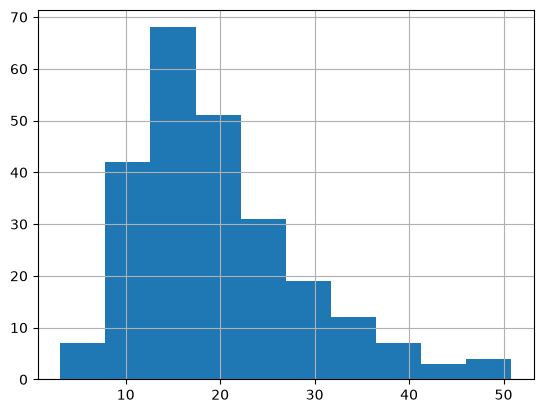

In [19]:
bill.hist()

c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

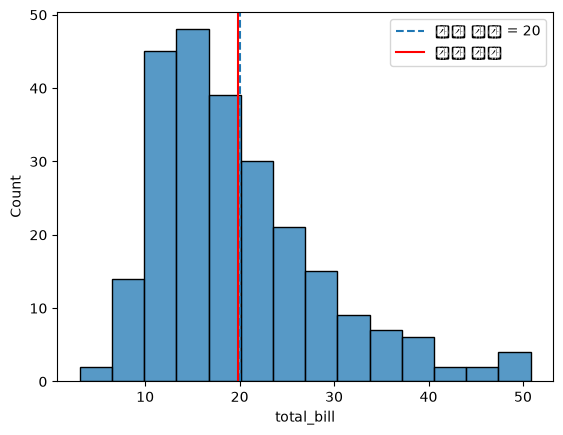

In [26]:
sns.histplot(bill)
plt.axvline(20, linestyle="--", label="기준 평균 = 20")
plt.axvline(bill.mean(), color="red", label="표본 평균")
plt.legend()
plt.show()

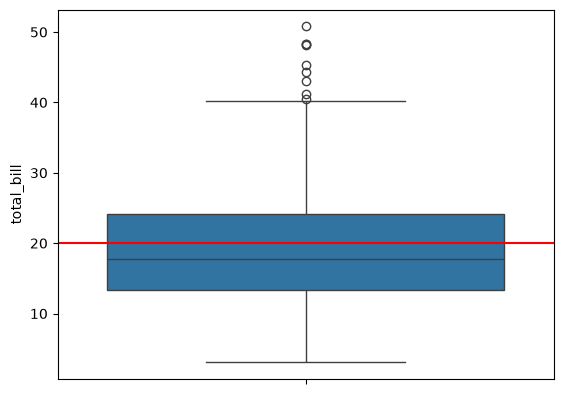

In [30]:
sns.boxplot(bill)
plt.axhline(20, color="red")

In [34]:
result = stats.ttest_1samp(bill, popmean=20)
result

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [35]:
stats.ttest_1samp(bill, 20)

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [40]:
result.confidence_interval

<bound method TtestResult.confidence_interval of TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))>

In [41]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 결제금액은 20달러와 통계적으로 다르다고 볼 수 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 결제금액이 20달러와 다르다고 볼 충분한 근거가 없다.")

귀무가설을 기각하지 못한다.
평균 결제금액이 20달러와 다르다고 볼 충분한 근거가 없다.


In [42]:
result

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [50]:
(bill.mean() - 20) / (bill.std()/np.sqrt(bill.count()))

np.float64(-0.37559294451919506)

In [52]:
stats.ttest_1samp(bill, 20)

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [53]:
stats.ttest_1samp(bill, 20, alternative="two-sided")

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))

In [54]:
stats.ttest_1samp(bill, 20, alternative="greater")

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.646226403218664), df=np.int64(243))

In [55]:
stats.ttest_1samp(bill, 20, alternative="less")

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.3537735967813361), df=np.int64(243))

In [56]:
se = bill.std()/np.sqrt(bill.count())
se

np.float64(0.5699185252885925)

In [57]:
bill.mean()-se, bill.mean()+se

(np.float64(19.216024097662228), np.float64(20.355861148239413))

In [59]:
t = stats.t.ppf(0.975, 243)
t

np.float64(1.9697743954267473)

In [60]:
bill.mean()-t*se

np.float64(18.66333170435798)

In [61]:
bill.mean()+t*se

np.float64(20.90855354154366)

In [62]:
bill.mean()-1.96*se, bill.mean()+1.96*se

(np.float64(18.66890231338518), np.float64(20.902982932516462))

In [63]:
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [64]:
stats.t.ppf(0.975, 243)

np.float64(1.9697743954267473)

In [65]:
result.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(18.66333170435798), high=np.float64(20.90855354154366))

In [66]:
bill.mean()-t*se, bill.mean()+t*se

(np.float64(18.66333170435798), np.float64(20.90855354154366))

In [67]:
stats.norm.ppf(0.95)

np.float64(1.6448536269514722)

In [69]:
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [71]:
stats.t.ppf(0.975, 243)

np.float64(1.9697743954267473)

In [72]:
result.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(18.66333170435798), high=np.float64(20.90855354154366))

표본 수: 244
표본평균: 19.78594262295082
표본표준편차: 8.902411954856856
중앙값: 17.795


c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_

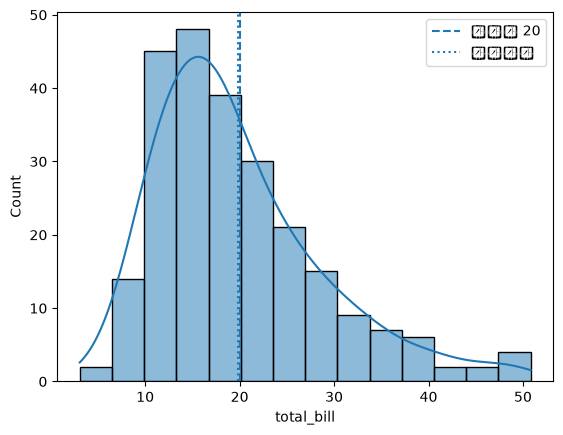

TtestResult(statistic=np.float64(-0.37559294451919506), pvalue=np.float64(0.7075471935626721), df=np.int64(243))
귀무가설을 기각하지 못한다.
평균 총 결제금액이 20달러와 다르다는 통계적 근거가 부족하다.
직접 계산한 t 통계량: -0.37559294451919506
직접 계산한 p-value: 0.7075471935626721
95% 신뢰구간: 18.66333170435798 20.90855354154366


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
tips = sns.load_dataset("tips")


# 2. 분석할 변수 선택 및 결측치 제거
bill = tips["total_bill"].dropna()


# 3. 데이터 확인
print("표본 수:", bill.count())
print("표본평균:", bill.mean())
print("표본표준편차:", bill.std(ddof=1))
print("중앙값:", bill.median())


# 4. 시각화
sns.histplot(bill, kde=True)
plt.axvline(
    20,
    linestyle="--",
    label="기준값 20"
)
plt.axvline(
    bill.mean(),
    linestyle=":",
    label="표본평균"
)
plt.legend()
plt.show()


# 5. 가설검정
# H0: 평균 총 결제금액은 20달러이다.
# H1: 평균 총 결제금액은 20달러가 아니다.

result = stats.ttest_1samp(
    bill,
    popmean=20,
    alternative="two-sided"
)

print(result)


# 6. 결과 해석
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 총 결제금액은 20달러와 통계적으로 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 총 결제금액이 20달러와 다르다는 통계적 근거가 부족하다.")


# 7. t 통계량 직접 계산
sample_mean = bill.mean()
sample_std = bill.std(ddof=1)
n = bill.count()
pop_mean = 20

standard_error = sample_std / np.sqrt(n)

t_stat = (
    sample_mean - pop_mean
) / standard_error

print("직접 계산한 t 통계량:", t_stat)


# 8. p-value 직접 계산
df = n - 1

p_value = 2 * stats.t.sf(
    np.abs(t_stat),
    df=df
)

print("직접 계산한 p-value:", p_value)


# 9. 95% 신뢰구간
critical_t = stats.t.ppf(
    0.975,
    df=df
)

margin_error = critical_t * standard_error

lower = sample_mean - margin_error
upper = sample_mean + margin_error

print("95% 신뢰구간:", lower, upper)

In [4]:
tip = tips.tip

In [6]:
tip.describe()

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

In [7]:
stats.ttest_1samp(tip, 3)

TtestResult(statistic=np.float64(-0.019432641422916876), pvalue=np.float64(0.9845119176410543), df=np.int64(243))

In [12]:
# p-value는 0.98로 0.98 > 0.05 이므로 H0를 기각하지 못한다. 따라서 tip은 3달러와 다르다고 볼 근거가 부족하다

In [9]:
stats.ttest_1samp(tip, 3, alternative="two-sided")

TtestResult(statistic=np.float64(-0.019432641422916876), pvalue=np.float64(0.9845119176410543), df=np.int64(243))

In [10]:
tip.isna().sum()

np.int64(0)

In [11]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 팁 금액은 3달러와 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 팁 금액이 3달러와 다르다고 볼 근거가 부족하다.")

귀무가설을 기각하지 못한다.
평균 팁 금액이 3달러와 다르다고 볼 근거가 부족하다.


In [ ]:
# H0: mu <= 2.5
# H1: mu > 2.5

In [13]:
stats.ttest_1samp(tip, 2.5, alternative="greater")

TtestResult(statistic=np.float64(5.625287009994554), pvalue=np.float64(2.539994229843246e-08), df=np.int64(243))

In [14]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("평균 팁 금액은 2.5달러보다 크다고 볼 수 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("평균 팁 금액이 2.5달러보다 크다고 볼 근거가 부족하다.")

귀무가설을 기각하지 못한다.
평균 팁 금액이 2.5달러보다 크다고 볼 근거가 부족하다.


In [15]:
# p-value가 2.54로 0.05보다 크므로 H0를 기각하지 못한다. 따라서 평균 팁 금액이 2.5달러보다 크다고 볼 근거가 부족하다

In [16]:
weights = np.array([
    498, 503, 501, 497, 504,
    499, 502, 500, 505, 496,
    501, 499, 503, 498, 500,
    502, 497, 504, 501, 499
])

In [23]:
# H0 = 500
# H1 != 500

In [24]:
len(weights)

20

In [25]:
stats.ttest_1samp(weights, 500, alternative="two-sided")

TtestResult(statistic=np.float64(0.7785526001758747), pvalue=np.float64(0.4458317162792534), df=np.int64(19))

In [27]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설 기각")
    print("제품 평균 무게는 500g과 다르다고 볼 수 있다.")
else:
    print("귀무가설을 기각하지 못함")
    print("제품 평균 무게가 500g과 다르다고 볼 근거가 부족하다.")

귀무가설을 기각하지 못함
제품 평균 무게가 500g과 다르다고 볼 근거가 부족하다.


In [28]:
# p-value가 0.446정도로 0.05보다 크므로, H0를 기각하지 못한다. 따라서 weights의 평균이 500과 다르다고 볼 근거가 부족하다.

In [29]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [30]:
# 남자 모집단 평균 mu1
# 여자 모집단 평균 mu2
# H0: mu1 = mu2
# H1: mu1 != mu2

In [31]:
tips['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [34]:
tips.groupby('sex')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
sex,,,,
Male,157,20.744076,9.246469,18.35
Female,87,18.056897,8.009209,16.40


In [42]:
male_bill = tips.loc[tips.sex == 'Male','total_bill']
male_bill

1      10.34
2      21.01
3      23.68
5      25.29
6       8.77
       ...  
236    12.60
237    32.83
239    29.03
241    22.67
242    17.82
Name: total_bill, Length: 157, dtype: float64

In [43]:
female_bill = tips.loc[tips['sex']=='Female', 'total_bill']
female_bill

0      16.99
4      24.59
11     35.26
14     14.83
16     10.33
       ...  
226    10.09
229    22.12
238    35.83
240    27.18
243    18.78
Name: total_bill, Length: 87, dtype: float64

In [44]:
male_bill.mean(), female_bill.mean()

(np.float64(20.744076433121016), np.float64(18.056896551724133))

In [45]:
male_bill.mean()-female_bill.mean()

np.float64(2.687179881396883)

<Axes: xlabel='sex', ylabel='total_bill'>

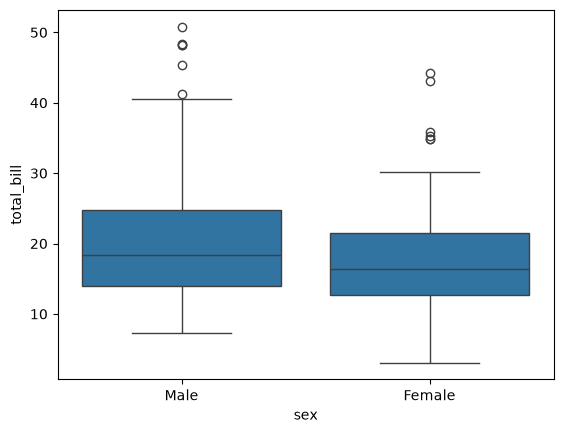

In [49]:
sns.boxplot(tips, x='sex', y='total_bill')

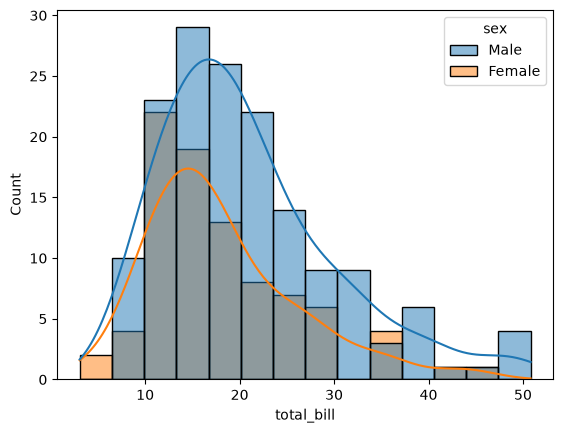

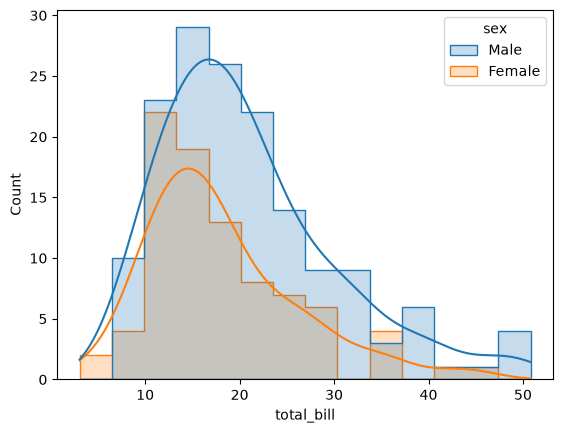

In [56]:
sns.histplot(tips, x='total_bill', hue='sex', kde=True)
plt.show()
sns.histplot(tips, x='total_bill', hue='sex', kde=True, element='step')
plt.show()

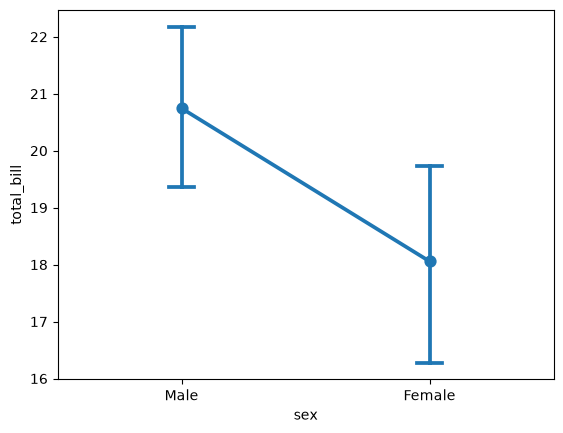

In [57]:
sns.pointplot(
    data=tips,
    x="sex",
    y="total_bill",
    errorbar=("ci", 95),
    capsize=0.1
)

plt.show()

In [ ]:
# 정규성 확인: shapiro
# H0: 데이터가 정규분포를 따른다
# H1: 데이터가 정규분포를 따르지 않는다

In [61]:
print(stats.shapiro(male_bill).pvalue)

1.0274536685915797e-07


In [62]:
if stats.shapiro(male_bill).pvalue < 0.05:
    print("남성 집단은 정규성을 만족하지 않는다고 판단")
else:
    print("남성 집단의 정규성을 기각하지 못함")

남성 집단은 정규성을 만족하지 않는다고 판단


In [63]:
stats.shapiro(female_bill).pvalue

np.float64(4.211812241575293e-05)

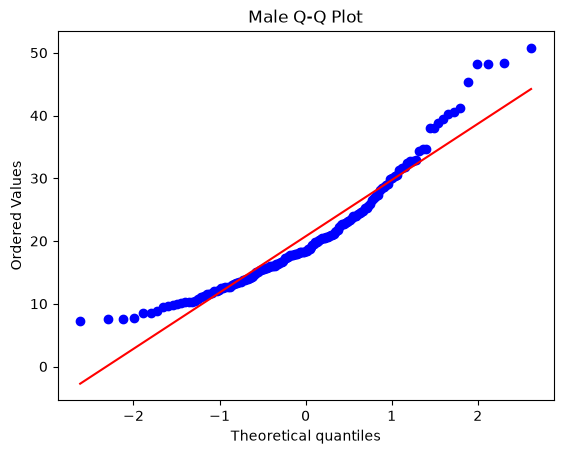

In [64]:
stats.probplot(
    male_bill,
    dist="norm",
    plot=plt
)

plt.title("Male Q-Q Plot")
plt.show()

((array([-2.61932342, -2.3011455 , -2.11897341, -1.98808743, -1.88439676,
         -1.79772477, -1.72277103, -1.65640788, -1.59662845, -1.54206475,
         -1.49174058, -1.44493383, -1.40109463, -1.35979412, -1.32069108,
         -1.28350932, -1.24802199, -1.21404037, -1.18140564, -1.14998288,
         -1.11965636, -1.09032607, -1.06190494, -1.03431666, -1.00749397,
         -0.98137721, -0.95591324, -0.9310545 , -0.9067582 , -0.88298572,
         -0.85970207, -0.83687542, -0.81447672, -0.79247938, -0.77085899,
         -0.74959307, -0.72866087, -0.70804319, -0.68772219, -0.6676813 ,
         -0.64790506, -0.62837904, -0.60908972, -0.59002442, -0.57117122,
         -0.5525189 , -0.53405686, -0.51577509, -0.49766411, -0.47971492,
         -0.46191898, -0.44426815, -0.42675466, -0.40937111, -0.3921104 ,
         -0.37496573, -0.35793059, -0.34099869, -0.324164  , -0.30742069,
         -0.29076313, -0.27418586, -0.25768361, -0.24125123, -0.22488375,
         -0.2085763 , -0.19232412, -0.

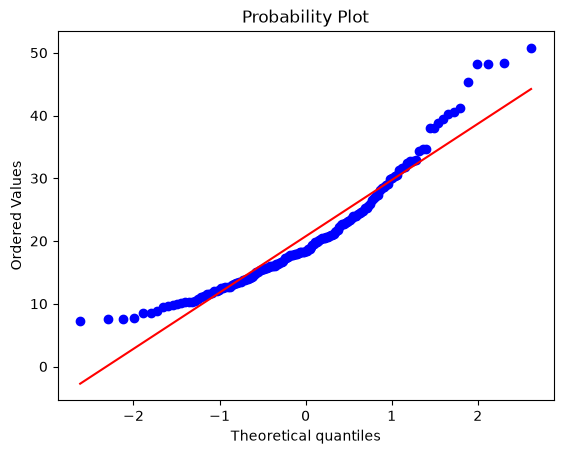

In [68]:
stats.probplot(male_bill, dist='norm', plot=plt)

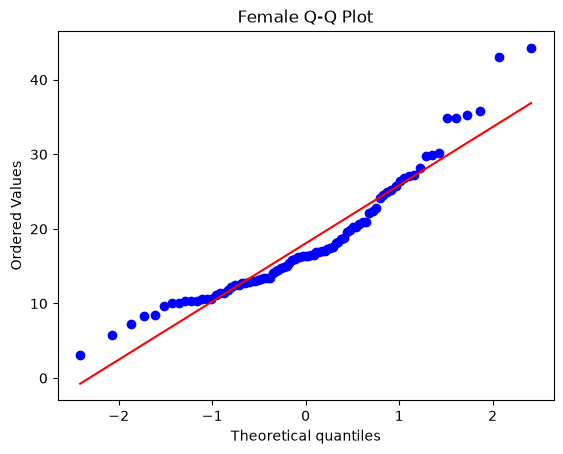

In [69]:
stats.probplot(
    female_bill,
    dist="norm",
    plot=plt
)

plt.title("Female Q-Q Plot")
plt.show()

In [ ]:
# 등분산성 확인
# H0: 두 집단의 분산이 같다
# H1: 두 집단의 분산이 다르다

stats.levene(male_bill, female_bill)

LeveneResult(statistic=np.float64(1.631715567905501), pvalue=np.float64(0.20269005267784007))

In [72]:
if stats.levene(male_bill, female_bill).pvalue < 0.05:
    print('H0 기각: 두 집단의 분산은 다르다')
else:
    print('H0를 기각하지 못한다: 두 집단의 분산은 같다')

H0를 기각하지 못한다: 두 집단의 분산은 같다


In [74]:
ttest = stats.ttest_ind(male_bill, female_bill, equal_var=True, alternative='two-sided')
ttest

TtestResult(statistic=np.float64(2.2777940289803134), pvalue=np.float64(0.023611666846859423), df=np.float64(242.0))

In [75]:
# H0: 남자와 여자의 total_bill의 평균은 같다
# H1: 남자와 여자의 total_bill의 평균은 다르다

In [76]:
if ttest.pvalue < 0.05:
    print('H0 기각: H1 채택 (평균은 다르다)')
else:
    print('H0 기각 못함: H0를 기각할 근거가 부족하므로 두 집단의 평균은 같다')

H0 기각: H1 채택 (평균은 다르다)


In [78]:
alpha = 0.05

if ttest.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("남성과 여성 고객의 평균 결제금액은 통계적으로 유의한 차이가 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("남성과 여성 고객의 평균 결제금액이 다르다고 볼 근거가 부족하다.")

귀무가설을 기각한다.
남성과 여성 고객의 평균 결제금액은 통계적으로 유의한 차이가 있다.


In [79]:
# H0 기각: 남성과 여성 고객의 평균 결제금액은 통계적으로 유의미한 차이가 있다.
# H1 기각: 남성과 여성 고객의 평균 결제금액은 다르다고 볼 근거가 부족하다.

In [80]:
stats.ttest_ind(male_bill, female_bill, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(2.3733978410287073), pvalue=np.float64(0.01857339485492169), df=np.float64(199.8482620471115))

In [81]:
alpha = 0.05

levene_result = stats.levene(
    male_bill,
    female_bill
)

if levene_result.pvalue >= alpha:
    equal_var = True
    variance_message = "등분산을 가정한 Student t-test"
else:
    equal_var = False
    variance_message = "등분산을 가정하지 않은 Welch t-test"

result = stats.ttest_ind(
    male_bill,
    female_bill,
    equal_var=equal_var,
    alternative="two-sided"
)

print("사용한 검정:", variance_message)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("두 집단의 평균에는 유의한 차이가 있다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print("두 집단의 평균이 다르다고 볼 근거가 부족하다.")

사용한 검정: 등분산을 가정한 Student t-test
t 통계량: 2.2777940289803134
p-value: 0.023611666846859423
귀무가설을 기각한다.
두 집단의 평균에는 유의한 차이가 있다.


In [82]:
stats.ttest_ind(male_bill, female_bill)

TtestResult(statistic=np.float64(2.2777940289803134), pvalue=np.float64(0.023611666846859423), df=np.float64(242.0))

In [83]:
stats.ttest_ind(female_bill, male_bill)

TtestResult(statistic=np.float64(-2.2777940289803134), pvalue=np.float64(0.023611666846859423), df=np.float64(242.0))

In [85]:
result_greater = stats.ttest_ind(
    male_bill,
    female_bill,
    equal_var=True,
    alternative="less"
)

print(result_greater)

TtestResult(statistic=np.float64(2.2777940289803134), pvalue=np.float64(0.9881941665765703), df=np.float64(242.0))


In [87]:
ttest.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(0.3633316619468365), high=np.float64(5.0110281008469295))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
        count       mean       std  median
sex                                       
Male      157  20.744076  9.246469   18.35
Female  

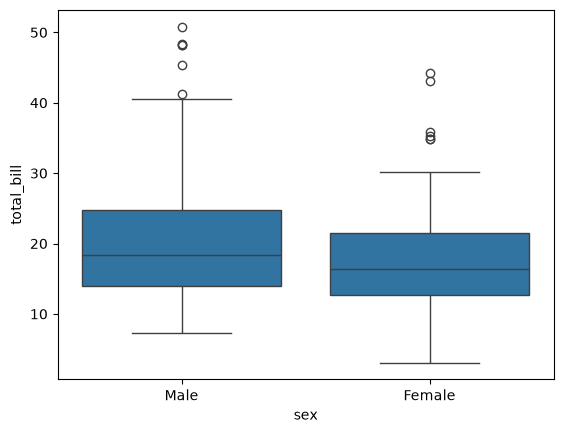

남성 정규성 p-value: 1.0274536685915797e-07
여성 정규성 p-value: 4.211812241575293e-05
Levene 통계량: 1.631715567905501
Levene p-value: 0.20269005267784007
사용한 검정: Student 독립표본 t-test
t 통계량: 2.2777940289803134
p-value: 0.023611666846859423
귀무가설을 기각한다.
남성과 여성 고객의 평균 결제금액에는 통계적으로 유의한 차이가 있다.
Cohen's d: 0.30443873648074676


In [88]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
tips = sns.load_dataset("tips")


# 2. 데이터 확인
print(tips.head())
print(tips.info())


# 3. 집단별 기초통계
summary = tips.groupby(
    "sex",
    observed=True
)["total_bill"].agg(
    ["count", "mean", "std", "median"]
)

print(summary)


# 4. 두 집단 분리
male_bill = tips.loc[
    tips["sex"] == "Male",
    "total_bill"
].dropna()

female_bill = tips.loc[
    tips["sex"] == "Female",
    "total_bill"
].dropna()


# 5. 집단별 평균 확인
print("남성 표본 수:", len(male_bill))
print("여성 표본 수:", len(female_bill))

print("남성 평균:", male_bill.mean())
print("여성 평균:", female_bill.mean())

print(
    "평균 차이:",
    male_bill.mean() - female_bill.mean()
)


# 6. 시각화
sns.boxplot(
    data=tips,
    x="sex",
    y="total_bill"
)

plt.show()


# 7. 정규성 검정
male_shapiro = stats.shapiro(male_bill)
female_shapiro = stats.shapiro(female_bill)

print("남성 정규성 p-value:", male_shapiro.pvalue)
print("여성 정규성 p-value:", female_shapiro.pvalue)


# 8. 등분산성 검정
levene_result = stats.levene(
    male_bill,
    female_bill
)

print("Levene 통계량:", levene_result.statistic)
print("Levene p-value:", levene_result.pvalue)


# 9. 등분산 여부에 따라 검정 선택
alpha = 0.05

if levene_result.pvalue >= alpha:
    equal_var = True
    test_name = "Student 독립표본 t-test"
else:
    equal_var = False
    test_name = "Welch 독립표본 t-test"


# 10. 독립표본 t-test
result = stats.ttest_ind(
    male_bill,
    female_bill,
    equal_var=equal_var,
    alternative="two-sided"
)

print("사용한 검정:", test_name)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)


# 11. 검정 결과 해석
if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "남성과 여성 고객의 평균 결제금액에는 "
        "통계적으로 유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "남성과 여성 고객의 평균 결제금액이 "
        "다르다고 볼 충분한 근거가 없다."
    )


# 12. Cohen's d 계산
n1 = len(male_bill)
n2 = len(female_bill)

var1 = male_bill.var(ddof=1)
var2 = female_bill.var(ddof=1)

pooled_variance = (
    ((n1 - 1) * var1)
    + ((n2 - 1) * var2)
) / (n1 + n2 - 2)

pooled_std = np.sqrt(pooled_variance)

cohens_d = (
    male_bill.mean()
    - female_bill.mean()
) / pooled_std

print("Cohen's d:", cohens_d)

In [89]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [90]:
tips['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [91]:
tips.groupby('smoker')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
smoker,,,,
Yes,93,20.756344,9.832154,17.92
No,151,19.188278,8.255582,17.59


In [92]:
# mu1: 흡연자, mu2: 비흡연자
# H0: mu1 = mu2 (흡연자와 비흡연자의 평균 결제 금액은 같다)
# H1: mu1 != m2 (흡연자와 비흡연자의 평균 결제 금액은 다르다)

In [95]:
smoker = tips.loc[tips['smoker']=='Yes', 'total_bill']
nonsmoker = tips.loc[tips['smoker']=='No', 'total_bill']

In [96]:
len(smoker), len(nonsmoker)

(93, 151)

In [ ]:
result = stats.ttest_ind(smoker, nonsmoker, )

In [99]:
# 등분산 검정
# H0: 두 집단의 분산은 같다
# h1: 두 집단의 분산은 다르다

lev = stats.levene(smoker, nonsmoker)

if lev.pvalue < 0.05:
    print('H0 기각: 두 집단의 분산은 통계적으로 유의미하게 차이가 있다.')
else:
    print('H0를 기각 할 수 없다. 따라서 두 집단의 분산은 다르다고 할 근거가 부족하다')

H0 기각: 두 집단의 분산은 통계적으로 유의미하게 차이가 있다.


In [98]:
stats.levene(smoker, nonsmoker)

LeveneResult(statistic=np.float64(4.053727631032653), pvalue=np.float64(0.04518116818962142))

In [100]:
# 정규성 확인: shapiro
# H0: 데이터가 정규분포를 따른다
# H1: 데이터가 정규분포를 따르지 않는다

In [101]:
stats.shapiro(smoker)

ShapiroResult(statistic=np.float64(0.9367441211736873), pvalue=np.float64(0.0002166644188825324))

In [102]:
stats.shapiro(nonsmoker)

ShapiroResult(statistic=np.float64(0.9045338652021683), pvalue=np.float64(2.2108584744714854e-08))

In [103]:
# 정규분포는 따르지 않는다. 또한 두 집단의 분산도 같지 않다

In [104]:
stats.ttest_ind(smoker, nonsmoker, equal_var=False, alternative="two-sided")

TtestResult(statistic=np.float64(1.2842515757360153), pvalue=np.float64(0.20080519917308057), df=np.float64(169.625891615264))

In [ ]:
# 귀무가설을 기각하지 못한다. 두 집단의 평균 결제 금액은 통계적으로 유의미하게 다르지 않다

In [108]:
smoker_tip = tips.loc[
    tips["smoker"] == "Yes",
    "tip"
].dropna()

non_smoker_tip = tips.loc[
    tips["smoker"] == "No",
    "tip"
].dropna()

levene_result = stats.levene(
    smoker_tip,
    non_smoker_tip
)

if levene_result.pvalue >= 0.05:
    equal_var = True
else:
    equal_var = False

print(equal_var)

result = stats.ttest_ind(
    smoker_tip,
    non_smoker_tip,
    equal_var=equal_var,
    alternative="two-sided"
)

print("흡연자 평균 팁:", smoker_tip.mean())
print("비흡연자 평균 팁:", non_smoker_tip.mean())
print("Levene p-value:", levene_result.pvalue)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

True
흡연자 평균 팁: 3.008709677419355
비흡연자 평균 팁: 2.9918543046357615
Levene p-value: 0.8862366542563253
t 통계량: 0.09222805186888201
p-value: 0.9265931522244977


In [107]:
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("흡연자와 비흡연자의 평균 팁 금액은 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "흡연자와 비흡연자의 평균 팁 금액이 "
        "다르다고 볼 근거가 부족하다."
    )

귀무가설을 기각하지 못한다.
흡연자와 비흡연자의 평균 팁 금액이 다르다고 볼 근거가 부족하다.


In [110]:
tips.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [114]:
tips.groupby('time')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
time,,,,
Lunch,68,17.168676,7.713882,15.965
Dinner,176,20.797159,9.142029,18.390


In [112]:
dinner = tips.loc[tips['time'] == 'Dinner', 'total_bill']
dinner

0      16.99
1      10.34
2      21.01
3      23.68
4      24.59
       ...  
239    29.03
240    27.18
241    22.67
242    17.82
243    18.78
Name: total_bill, Length: 176, dtype: float64

In [113]:
lunch = tips.loc[tips['time'] == 'Lunch', 'total_bill']
lunch

77     27.20
78     22.76
79     17.29
80     19.44
81     16.66
       ...  
222     8.58
223    15.98
224    13.42
225    16.27
226    10.09
Name: total_bill, Length: 68, dtype: float64

In [ ]:
# 정규성 검정
# H0: 데이터는 정규분포를 따른다
# H1: 데이터는 정규분포를 따르지 않는다

stats.shapiro(dinner), stats.shapiro(lunch)
# 점심/저녁 pvalue가 모두 0.05보다 작다. 따라서 두 집단의 데이터는 정규분포를 따르지 않는다.

(ShapiroResult(statistic=np.float64(0.9328960137022453), pvalue=np.float64(2.6869861734145505e-07)),
 ShapiroResult(statistic=np.float64(0.8687172285102468), pvalue=np.float64(3.64052067234852e-06)))

In [ ]:
# 등분산 검정
# H0: 두 집단의 분산은 같다
# H1: 두 집단의 분산은 다르다

stats.levene(lunch, dinner)
# pvalue는 0.1로 0.05보다 크다. 따라서 두 집단의 분산은 같다

LeveneResult(statistic=np.float64(2.6906995489829337), pvalue=np.float64(0.10223461077262591))

In [121]:
# mu1 = 점심 결제금액 평균
# mu2 = 저녁 결제금액 평균
# H0: mu1 = mu2 (점심과 저녁의 평균 결제금액은 같다)
# H1: mu1 != mu2 (점심과 저녁의 평균 결제금액은 다르다)

# 두 집단의 분산이 같으므로 equal_var=true
result = stats.ttest_ind(lunch, dinner, equal_var=True, alternative="two-sided")
result.pvalue

# pvalue가 0.0041로 0.05보다 작으므로 H0기각. 따라서 점심과 저녁의 평균 결제금액은 다르다. 통계적으로 유의미하게 차이가 있다

np.float64(0.004104621407595672)

In [123]:
lunch_bill = tips.loc[
    tips["time"] == "Lunch",
    "total_bill"
].dropna()

dinner_bill = tips.loc[
    tips["time"] == "Dinner",
    "total_bill"
].dropna()

levene_result = stats.levene(
    lunch_bill,
    dinner_bill
)

equal_var = (
    levene_result.pvalue >= 0.05
)
print(equal_var)

result = stats.ttest_ind(
    lunch_bill,
    dinner_bill,
    equal_var=equal_var,
    alternative="two-sided"
)

print("점심 평균:", lunch_bill.mean())
print("저녁 평균:", dinner_bill.mean())
print("등분산 검정 p-value:", levene_result.pvalue)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print("점심과 저녁의 평균 팁 금액은 다르다.")
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "점심과 저녁의 평균 팁 금액이 "
        "다르다고 볼 근거가 부족하다."
    )

True
점심 평균: 17.168676470588235
저녁 평균: 20.79715909090909
등분산 검정 p-value: 0.10223461077262591
t 통계량: -2.8976375218366424
p-value: 0.004104621407595672
귀무가설을 기각한다.
점심과 저녁의 평균 팁 금액은 다르다.


In [124]:
method_a = np.array([
    72, 75, 78, 74, 77,
    80, 76, 79, 73, 81
])

method_b = np.array([
    68, 70, 74, 69, 72,
    71, 73, 67, 75, 70
])

In [125]:
method_a.mean(), method_b.mean()

(np.float64(76.5), np.float64(70.9))

In [ ]:
# 둘 다 pvalue가 0.05보다 크다. 따라서 두 집단의 데이터 모두 정규분포를 따르지 않는다.
stats.shapiro(method_a), stats.shapiro(method_b)

(ShapiroResult(statistic=np.float64(0.9701646110856056), pvalue=np.float64(0.8923673061902978)),
 ShapiroResult(statistic=np.float64(0.9752339025839644), pvalue=np.float64(0.9346854448707653)))

In [ ]:
# pvalue가 0.54로 0.05보다 크다. 따라서 두 집단의 분산은 같다
stats.levene(method_a, method_b)

LeveneResult(statistic=np.float64(0.3749999999999998), pvalue=np.float64(0.5479501508336089))

In [131]:
# 두 집단의 분산이 같으므로 equal_var=True
# H0: 학습방법 A와 B의 평균 점수는 같다
# H1: 학습방법 A와 B의 평균 점수는 다르다

stats.ttest_ind(method_a, method_b, equal_var=True, alternative="two-sided")
# pvalue가 0.00032로 0.05보다 작으므로 H0 기각. 따라서 학습방법 A와 B의 평균 점수는 다르다. 통계적으로 유의미하게 다르다

TtestResult(statistic=np.float64(4.436440957366703), pvalue=np.float64(0.0003187250412675816), df=np.float64(18.0))

In [133]:
print("A 평균:", method_a.mean())
print("B 평균:", method_b.mean())

levene_result = stats.levene(
    method_a,
    method_b
)

equal_var = (
    levene_result.pvalue >= 0.05
)

print(equal_var)

result = stats.ttest_ind(
    method_a,
    method_b,
    equal_var=equal_var,
    alternative="two-sided"
)

print("Levene p-value:", levene_result.pvalue)
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

alpha = 0.05

if result.pvalue < alpha:
    print("두 학습 방법의 평균 점수는 유의하게 다르다.")
else:
    print(
        "두 학습 방법의 평균 점수가 다르다고 "
        "볼 충분한 근거가 없다."
    )

A 평균: 76.5
B 평균: 70.9
True
Levene p-value: 0.5479501508336089
t 통계량: 4.436440957366703
p-value: 0.0003187250412675816
두 학습 방법의 평균 점수는 유의하게 다르다.


In [136]:
from scipy import stats

In [137]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [142]:
flights.groupby('month')['passengers'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
month,,,,
Jan,12,241.750000,101.032960,223.0
Feb,12,235.000000,89.619397,214.5
Mar,12,270.166667,100.559194,251.5
Apr,12,267.083333,107.374839,252.0
May,12,271.833333,114.739890,252.0
Jun,12,311.666667,134.219856,289.5
Jul,12,351.333333,156.827255,333.0
Aug,12,351.083333,155.783333,320.0
Sep,12,302.416667,123.954140,285.5


In [143]:
flights['month'].value_counts()

month
Jan    12
Feb    12
Mar    12
Apr    12
May    12
Jun    12
Jul    12
Aug    12
Sep    12
Oct    12
Nov    12
Dec    12
Name: count, dtype: int64

In [144]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [147]:
jan = flights.loc[flights['month']=='Jan', ['year', 'passengers']]
feb = flights.loc[flights['month']=='Feb', ['year', 'passengers']]

In [160]:
jan['passengers'].values

array([112, 115, 145, 171, 196, 204, 242, 284, 315, 340, 360, 417])

In [165]:
paired = pd.merge(jan,feb, on='year')
paired

,year,passengers_x,passengers_y
0,1949,112,118
1,1950,115,126
2,1951,145,150
3,1952,171,180
4,1953,196,196
5,1954,204,188
6,1955,242,233
7,1956,284,277
8,1957,315,301
9,1958,340,318


In [167]:
paired.rename(columns={'passengers_x':'Jan', 'passengers_y':'Feb'}, inplace=True)

In [169]:
paired['difference'] = paired['Feb'] - paired['Jan']
paired

,year,Jan,Feb,difference
0,1949,112,118,6
1,1950,115,126,11
2,1951,145,150,5
3,1952,171,180,9
4,1953,196,196,0
5,1954,204,188,-16
6,1955,242,233,-9
7,1956,284,277,-7
8,1957,315,301,-14
9,1958,340,318,-22


<Axes: >

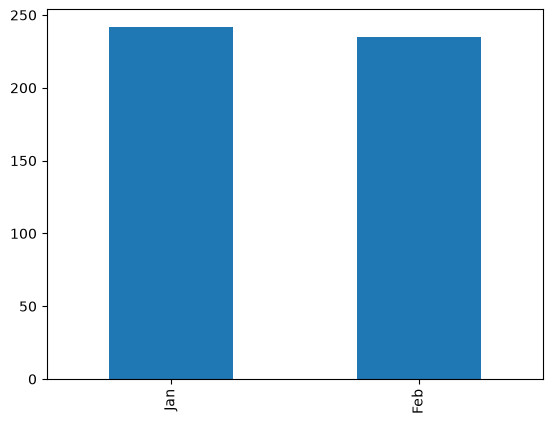

In [173]:
paired[['Jan', 'Feb']].mean().plot(kind='bar')

<Axes: xlabel='difference', ylabel='Count'>

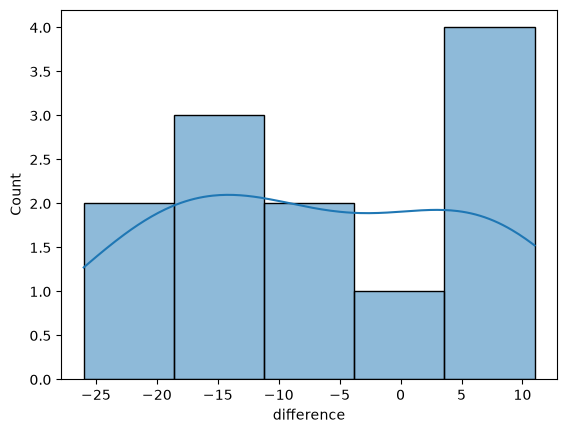

In [175]:
sns.histplot(paired['difference'], kde=True)

<Axes: xlabel='difference'>

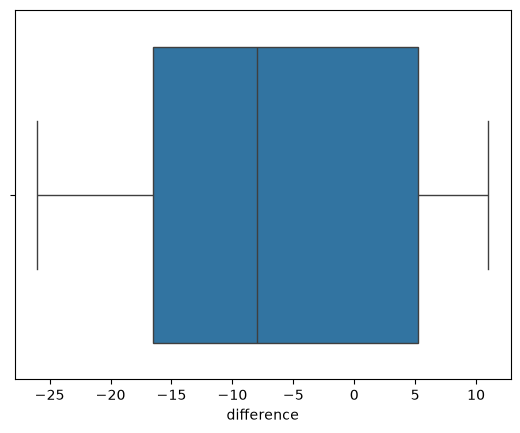

In [176]:
sns.boxplot(x=paired['difference'])

In [179]:
# pvalue가 0.47정도로 0.05보다 크므로, 정규성을 만족한다
result = stats.shapiro(paired['difference'])

alpha = 0.05

if result.pvalue < alpha:
    print("차이값의 정규성을 기각한다.")
else:
    print("차이값의 정규성을 기각하지 못한다.")

차이값의 정규성을 기각하지 못한다.


In [181]:
# pvalue가 0.093정도로 0.05보다 크므로 H0를 기각할 수 없다. Jan과 Feb의 평균 고객 수는 차이가 있다고 할 근거가 부족하다.
result = stats.ttest_rel(paired['Jan'], paired['Feb'], alternative='two-sided')

alpha = 0.05

print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수에는 유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수가 다르다고 볼 "
        "충분한 근거가 없다."
    )

t 통계량: 1.836988454391655
p-value: 0.09335550148616216
귀무가설을 기각하지 못한다.
같은 연도에서 1월과 2월의 평균 승객 수가 다르다고 볼 충분한 근거가 없다.


In [182]:
stats.ttest_1samp(paired['difference'], 0, alternative='two-sided')

TtestResult(statistic=np.float64(-1.836988454391655), pvalue=np.float64(0.09335550148616216), df=np.int64(11))

In [183]:
result.confidence_interval(0.95)

ConfidenceInterval(low=np.float64(-1.3375031060217264), high=np.float64(14.837503106021726))

    year  passengers_jan  passengers_feb  difference
0   1949             112             118           6
1   1950             115             126          11
2   1951             145             150           5
3   1952             171             180           9
4   1953             196             196           0
5   1954             204             188         -16
6   1955             242             233          -9
7   1956             284             277          -7
8   1957             315             301         -14
9   1958             340             318         -22
10  1959             360             342         -18
11  1960             417             391         -26
1월 평균: 241.75
2월 평균: 235.0
평균 차이: -6.75


c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

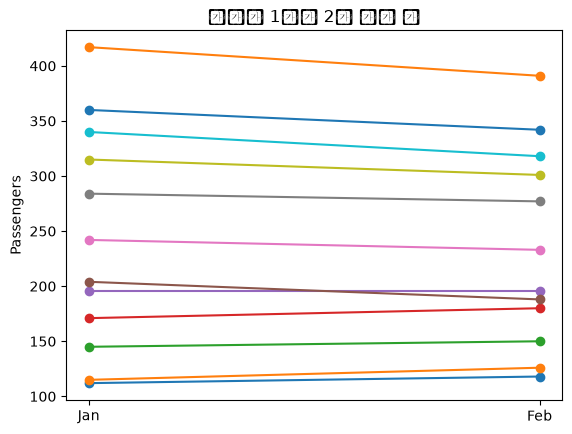

c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ajb\git\big0611\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

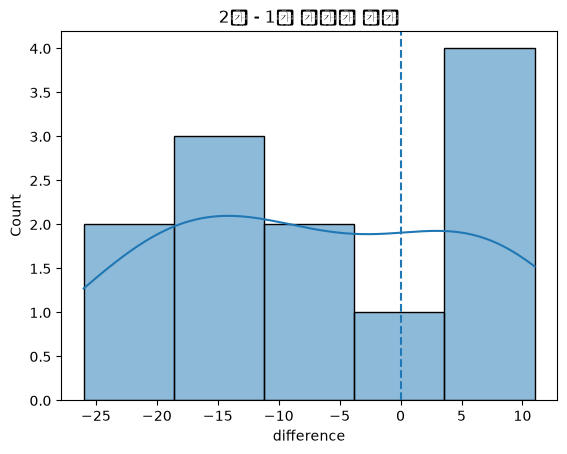

Shapiro 통계량: 0.9378836847705214
Shapiro p-value: 0.47115216055931236
t 통계량: -1.836988454391655
p-value: 0.09335550148616216
귀무가설을 기각하지 못한다.
같은 연도에서 1월과 2월의 평균 승객 수가 다르다고 볼 충분한 근거가 없다.
차이값 일표본 검정:
TtestResult(statistic=np.float64(-1.836988454391655), pvalue=np.float64(0.09335550148616216), df=np.int64(11))
Cohen's dz: -0.5302928893206283
평균 차이의 95% 신뢰구간: -14.837503106021728 1.3375031060217282


In [184]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats


# 1. 데이터 불러오기
flights = sns.load_dataset("flights")


# 2. 1월과 2월 데이터 추출
jan = flights.loc[
    flights["month"] == "Jan",
    ["year", "passengers"]
].copy()

feb = flights.loc[
    flights["month"] == "Feb",
    ["year", "passengers"]
].copy()


# 3. 연도를 기준으로 짝짓기
paired = pd.merge(
    jan,
    feb,
    on="year",
    suffixes=("_jan", "_feb")
)


# 4. 차이값 계산
paired["difference"] = (
    paired["passengers_feb"]
    - paired["passengers_jan"]
)


# 5. 데이터 확인
print(paired)

print(
    "1월 평균:",
    paired["passengers_jan"].mean()
)

print(
    "2월 평균:",
    paired["passengers_feb"].mean()
)

print(
    "평균 차이:",
    paired["difference"].mean()
)


# 6. 대응 관계 시각화
for _, row in paired.iterrows():
    plt.plot(
        ["Jan", "Feb"],
        [
            row["passengers_jan"],
            row["passengers_feb"]
        ],
        marker="o"
    )

plt.ylabel("Passengers")
plt.title("연도별 1월과 2월 승객 수")
plt.show()


# 7. 차이값 분포 확인
sns.histplot(
    paired["difference"],
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("2월 - 1월 차이값 분포")
plt.show()


# 8. 차이값 정규성 검정
shapiro_result = stats.shapiro(
    paired["difference"]
)

print(
    "Shapiro 통계량:",
    shapiro_result.statistic
)

print(
    "Shapiro p-value:",
    shapiro_result.pvalue
)


# 9. 대응표본 t-test
result = stats.ttest_rel(
    paired["passengers_feb"],
    paired["passengers_jan"],
    alternative="two-sided"
)

print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)


# 10. 검정 결과 해석
alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수에는 유의한 차이가 있다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "같은 연도에서 1월과 2월의 "
        "평균 승객 수가 다르다고 볼 "
        "충분한 근거가 없다."
    )


# 11. 차이값에 대한 일표본 t-test
difference_result = stats.ttest_1samp(
    paired["difference"],
    popmean=0
)

print("차이값 일표본 검정:")
print(difference_result)


# 12. 효과크기
cohens_dz = (
    paired["difference"].mean()
    / paired["difference"].std(ddof=1)
)

print("Cohen's dz:", cohens_dz)


# 13. 평균 차이의 95% 신뢰구간
difference = paired["difference"]

n = difference.count()

standard_error = stats.sem(
    difference
)

critical_t = stats.t.ppf(
    0.975,
    df=n - 1
)

margin_error = (
    critical_t * standard_error
)

lower = (
    difference.mean() - margin_error
)

upper = (
    difference.mean() + margin_error
)

print(
    "평균 차이의 95% 신뢰구간:",
    lower,
    upper
)

In [185]:
before = np.array([
    65, 70, 72, 68, 75,
    78, 74, 69, 71, 73
])

after = np.array([
    70, 74, 75, 72, 79,
    80, 78, 73, 74, 77
])

In [187]:
diff = after - before
diff

array([5, 4, 3, 4, 4, 2, 4, 4, 3, 4])

In [189]:
# pvalue는 0.045정도로 0.05보다 작으므로, H0 기각. 따라서 데이터들이 정규분포를 따른다고 할 수 없다
stats.shapiro(diff)

ShapiroResult(statistic=np.float64(0.840621887677894), pvalue=np.float64(0.04488770617062266))

In [194]:
# d= after-before
# H0: d <= 0
# H1: d > 0

print(stats.ttest_1samp(diff, 0, alternative='greater'))
print(stats.ttest_rel(after, before, alternative='greater'))
# pvalue가 매우 작으므로, H0 기각. 따라서 after와 before의 차이는 0보다 크다

TtestResult(statistic=np.float64(14.212093672551452), pvalue=np.float64(9.004156615213933e-08), df=np.int64(9))
TtestResult(statistic=np.float64(14.212093672551452), pvalue=np.float64(9.004156615213933e-08), df=np.int64(9))


In [193]:
result = stats.ttest_rel(
    after,
    before,
    alternative="greater"
)

print("교육 전 평균:", before.mean())
print("교육 후 평균:", after.mean())
print("평균 변화량:", (after - before).mean())
print("t 통계량:", result.statistic)
print("p-value:", result.pvalue)

alpha = 0.05

if result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "교육 후 평균 점수가 "
        "교육 전보다 유의하게 높아졌다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "교육 후 평균 점수가 높아졌다고 "
        "볼 충분한 근거가 없다."
    )

교육 전 평균: 71.5
교육 후 평균: 75.2
평균 변화량: 3.7
t 통계량: 14.212093672551452
p-value: 9.004156615213933e-08
귀무가설을 기각한다.
교육 후 평균 점수가 교육 전보다 유의하게 높아졌다.


In [195]:
stats.wilcoxon(
    after,
    before,
    alternative='greater'
)

WilcoxonResult(statistic=np.float64(55.0), pvalue=np.float64(0.0009765625))

In [199]:
print(f'{result.pvalue:0.8f}')

0.00000009


In [200]:
blood_pressure = pd.DataFrame({
    "patient_id": [
        "P01", "P02", "P03", "P04",
        "P05", "P06", "P07", "P08"
    ],
    "before": [
        150, 145, 160, 155,
        148, 152, 158, 147
    ],
    "after": [
        142, 139, 151, 149,
        143, 146, 150, 141
    ]
})

In [ ]:
# 치료 후 혈압이 치료 전보다 낮아졌다고 할 수 있는지 검정하세요.
# d = after - before
# H0: d >= 0 (치료 후 혈압이 치료 전보다 크거나 같다)
# H1: d < 0 (치료 후 혈압이 치료 전보다 작다)
# H0: after >= before
# H1: after < before

print(stats.ttest_rel(blood_pressure['after'], blood_pressure['before'], alternative='less'))
print(stats.ttest_1samp(blood_pressure['after']-blood_pressure['before'], 0, alternative='less'))
# pvalue가 매우 작으므로, H0 기각. 따라서 치료 후 혈압이 치료전보다 작다. 즉 치료 후 효과가 있다.

TtestResult(statistic=np.float64(-13.74772708486752), pvalue=np.float64(1.2704952772255126e-06), df=np.int64(7))
TtestResult(statistic=np.float64(-13.74772708486752), pvalue=np.float64(1.2704952772255126e-06), df=np.int64(7))


In [203]:
blood_pressure

,patient_id,before,after
0,P01,150,142
1,P02,145,139
2,P03,160,151
3,P04,155,149
4,P05,148,143
5,P06,152,146
6,P07,158,150
7,P08,147,141


In [207]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [208]:
tips = sns.load_dataset("tips")

In [209]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [210]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [214]:
tips[['day', 'total_bill']]

,day,total_bill
0,Sun,16.99
1,Sun,10.34
2,Sun,21.01
3,Sun,23.68
4,Sun,24.59
...,...,...
239,Sat,29.03
240,Sat,27.18
241,Sat,22.67
242,Sat,17.82


In [216]:
tips.groupby('day')['total_bill'].agg(['count', 'mean', 'std', 'median'])

,count,mean,std,median
day,,,,
Thur,62,17.682742,7.886170,16.20
Fri,19,17.151579,8.302660,15.38
Sat,87,20.441379,9.480419,18.24
Sun,76,21.410000,8.832122,19.63


In [217]:
tips['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

<Axes: xlabel='day', ylabel='total_bill'>

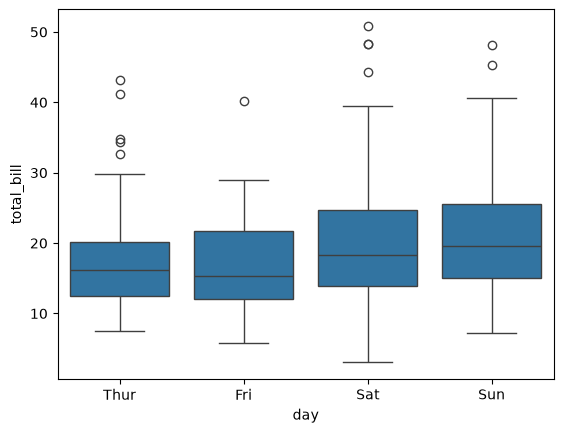

In [219]:
sns.boxplot(tips, x='day', y='total_bill')

In [221]:
thur_bill = tips.loc[
    tips["day"] == "Thur",
    "total_bill"
].dropna()

fri_bill = tips.loc[
    tips["day"] == "Fri",
    "total_bill"
].dropna()

sat_bill = tips.loc[
    tips["day"] == "Sat",
    "total_bill"
].dropna()

sun_bill = tips.loc[
    tips["day"] == "Sun",
    "total_bill"
].dropna()

In [222]:
stats.shapiro(thur_bill)

ShapiroResult(statistic=np.float64(0.8844888694104517), pvalue=np.float64(2.85715908758707e-05))

In [223]:
groups = {'thur':thur_bill, 'fri':fri_bill, 'sat':sat_bill, 'sun':sun_bill}

In [233]:
groups.keys()

dict_keys(['thur', 'fri', 'sat', 'sun'])

In [235]:
for key, value in groups.items():
    print(f"{key}: {stats.shapiro(value).pvalue}")

thur: 2.85715908758707e-05
fri: 0.04085649671549424
sat: 7.991754612612711e-06
sun: 0.0035657960627037966


In [236]:
alpha = 0.05

for name, values in groups.items():
    result = stats.shapiro(values)

    if result.pvalue < alpha:
        print(name, ": 정규성 기각")
    else:
        print(name, ": 정규성을 기각하지 못함")

thur : 정규성 기각
fri : 정규성 기각
sat : 정규성 기각
sun : 정규성 기각


In [238]:
levene_result = stats.levene(thur_bill, fri_bill, sat_bill, sun_bill)

if levene_result.pvalue < 0.05:
    print("등분산 가정을 만족하지 않는다.")
else:
    print("등분산 가정을 기각하지 못한다.")

등분산 가정을 기각하지 못한다.


In [241]:
# pvalue가 0.04정도로 0.05보다 작으므로 H0 기각. 따라서 적어도 1개는 평균이 다르다
anova_result = stats.f_oneway(thur_bill, fri_bill, sat_bill, sun_bill)

alpha = 0.05

print("F 통계량:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

if anova_result.pvalue < alpha:
    print("귀무가설을 기각한다.")
    print(
        "요일별 평균 총 결제금액 중 "
        "적어도 하나는 다르다."
    )
else:
    print("귀무가설을 기각하지 못한다.")
    print(
        "요일별 평균 총 결제금액이 "
        "다르다고 볼 충분한 근거가 없다."
    )

F 통계량: 2.767479443286335
p-value: 0.04245383328952
귀무가설을 기각한다.
요일별 평균 총 결제금액 중 적어도 하나는 다르다.


In [242]:
for key, value in groups.items():
    print(f'{key}: {len(value)}')

thur: 62
fri: 19
sat: 87
sun: 76


In [243]:
stats.f_oneway(thur_bill, fri_bill, sat_bill, sun_bill)

F_onewayResult(statistic=np.float64(2.767479443286335), pvalue=np.float64(0.04245383328952))

In [ ]:
pairwise_tukeyhsd

In [244]:
tukey_result = pairwise_tukeyhsd(
    endog=tips["total_bill"],
    groups=tips["day"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Fri    Sat   3.2898 0.4541 -2.4799  9.0595  False
   Fri    Sun   4.2584 0.2371 -1.5856 10.1025  False
   Fri   Thur   0.5312 0.9957 -5.4434  6.5057  False
   Sat    Sun   0.9686 0.8968 -2.6088   4.546  False
   Sat   Thur  -2.7586 0.2374 -6.5455  1.0282  False
   Sun   Thur  -3.7273 0.0668 -7.6264  0.1719  False
----------------------------------------------------


In [245]:
tukey_result.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
Fri,Sat,3.2898,0.4541,-2.4799,9.0595,False
Fri,Sun,4.2584,0.2371,-1.5856,10.1025,False
Fri,Thur,0.5312,0.9957,-5.4434,6.5057,False
Sat,Sun,0.9686,0.8968,-2.6088,4.546,False
Sat,Thur,-2.7586,0.2374,-6.5455,1.0282,False
Sun,Thur,-3.7273,0.0668,-7.6264,0.1719,False
